# Semana 2 — Intuición, técnica y juicio profesional

Lee el marco de la semana. En cada experimento: predice, ejecuta, explica y cambia una condición. Las salidas docentes no reemplazan tus conclusiones.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
# Encuentra la raíz tanto desde la carpeta del notebook como desde la raíz del libro.
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'sa_mise' / '__init__.py').exists())
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from sa_mise import datos, modelos, expediente
plt.rcParams.update({'figure.figsize': (10, 4), 'axes.grid': True, 'grid.alpha': .2})

## Capa 1. Dibuja a tus seis amigos
Recuperamos exactamente los siete enlaces del ejemplo de la lectura. Antes de usar una métrica, cuenta los vecinos de A y piensa qué ocurre con E si B sale de la conversación.

Vecinos de A: ['B', 'C', 'D']


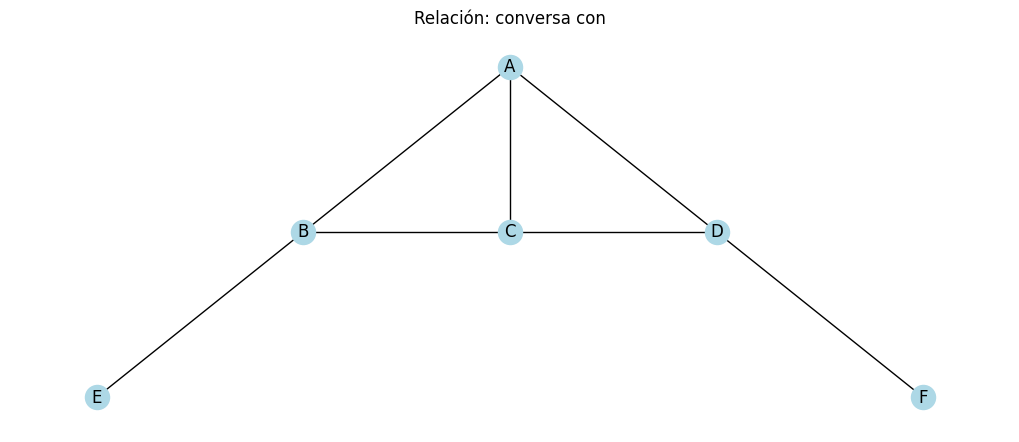

In [2]:
import networkx as nx
amigos=nx.Graph()
amigos.add_edges_from([('A','B'),('A','C'),('A','D'),('B','C'),('B','E'),('C','D'),('D','F')])
pos_amigos={'A':(0,1),'B':(-1,0),'C':(0,0),'D':(1,0),'E':(-2,-1),'F':(2,-1)}
nx.draw(amigos,pos=pos_amigos,with_labels=True,node_color='lightblue');plt.title('Relación: conversa con');plt.show()
print('Vecinos de A:',list(amigos.neighbors('A')))

La figura ayuda a localizar relaciones, pero las distancias en el dibujo no son distancias medidas entre personas. A tiene tres vecinos; B y D conectan a los dos participantes periféricos. Conserva esta distinción antes de calcular intermediación.

## Capa 2. De la lista a la matriz y a las métricas
El orden de filas y columnas debe ser el mismo. Sumar la fila equivale a contar enlaces. Después compara dos medidas diferentes: grado e intermediación.

In [3]:
orden=sorted(amigos)
ady=nx.to_pandas_adjacency(amigos,nodelist=orden,dtype=int)
display(ady)
display(pd.DataFrame({'grado':ady.sum(axis=1),'intermediacion':nx.betweenness_centrality(amigos),
                     'clustering':nx.clustering(amigos)}))
print('Caminos mínimos E-F:',list(nx.all_shortest_paths(amigos,'E','F')))
print('Densidad:',nx.density(amigos),'Clustering A:',nx.clustering(amigos,'A'))
assert np.isclose(nx.density(amigos),7/15)
assert np.isclose(nx.clustering(amigos,'A'),2/3)

Caminos mínimos E-F: [['E', 'B', 'A', 'D', 'F'], ['E', 'B', 'C', 'D', 'F']]
Densidad: 0.4666666666666667 Clustering A: 0.6666666666666666


,A,B,C,D,E,F
A,0,1,1,1,0,0
B,1,0,1,0,1,0
C,1,1,0,1,0,0
D,1,0,1,0,0,1
E,0,1,0,0,0,0
F,0,0,0,1,0,0


,grado,intermediacion,clustering
A,3,0.2,0.666667
B,3,0.4,0.333333
C,3,0.2,0.666667
D,3,0.4,0.333333
E,1,0.0,0.000000
F,1,0.0,0.000000


Los cuatro nodos del núcleo empatan en grado, pero no cumplen el mismo papel de intermediación. El clustering de A es 2/3 porque dos de los tres pares entre sus vecinos están conectados. La densidad usa otro denominador: los quince pares posibles de toda la red. Ninguna medida significa por sí sola «poder».

### Una intervención que podemos entender sin una caja negra
Quitamos B del caso base; después añadimos E–F al caso base y volvemos a quitar B. Así aislamos el efecto de una nueva relación.

In [4]:
sin_b=amigos.copy();sin_b.remove_node('B')
alternativa=amigos.copy();alternativa.add_edge('E','F');alternativa.remove_node('B')
print('Sin B:',[sorted(c) for c in nx.connected_components(sin_b)])
print('Con enlace adicional, sin B:',[sorted(c) for c in nx.connected_components(alternativa)])

Sin B: [['A', 'C', 'D', 'F'], ['E']]
Con enlace adicional, sin B: [['A', 'C', 'D', 'E', 'F']]


La nueva relación permite que E conserve acceso al grupo por F y D. Esto es una conclusión de conectividad. Para estudiar velocidad de rumor falta una regla de difusión. Para estudiar energía hacen falta ecuaciones eléctricas. El próximo bloque usa cinco barras ficticias, un objeto diferente.

## Capa 3. De caminos a flujos y restricciones
Antes de mirar los resultados DC, predice si una modificación de reactancia puede cambiar flujos sin cambiar el grado. Ese contraste permitirá ponderar análisis topológico y eléctrico.

## 1. Topología de una red ficticia
Las barras A–E no son subestaciones colombianas. Las aristas llevan reactancia pu y límite MW del ejercicio. Contar caminos y resolver flujos responde a preguntas diferentes. Una contingencia empieza de nuevo desde el caso base; no se acumulan salidas.

,grado,intermediacion
A,2,0.000000
B,3,0.250000
C,3,0.250000
D,2,0.083333
E,2,0.083333


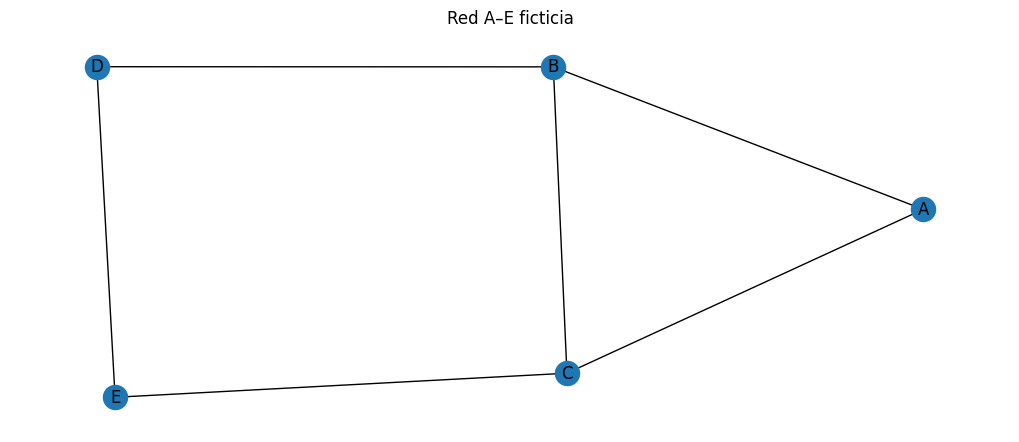

,origen,destino,flujo_MW,limite_MW,carga_pct
0,A,B,60.151515,65,92.540793
1,A,C,39.848485,65,61.305361
2,B,C,13.030303,40,32.575758
3,B,D,47.121212,55,85.674931
4,C,E,62.878788,65,96.736597
5,D,E,-7.878788,50,15.757576


,salida,conectado,max_carga_pct,alcance
0,A–B,True,153.846154,DC despacho fijo; no certifica N-1 integral
1,A–C,True,153.846154,DC despacho fijo; no certifica N-1 integral
2,B–C,True,95.151515,DC despacho fijo; no certifica N-1 integral
3,B–D,True,169.230769,DC despacho fijo; no certifica N-1 integral
4,C–E,True,200.000000,DC despacho fijo; no certifica N-1 integral
5,D–E,True,100.000000,DC despacho fijo; no certifica N-1 integral


In [5]:
import networkx as nx
G,inyecciones=modelos.red_docente()
display(pd.DataFrame({'grado':dict(G.degree()),'intermediacion':nx.betweenness_centrality(G)}))
nx.draw(G,with_labels=True,pos=nx.spring_layout(G,seed=42));plt.title('Red A–E ficticia');plt.show()
base=modelos.flujo_dc(G,inyecciones);display(base)
display(modelos.contingencias_dc(G,inyecciones))

## 2. Misma topología, otro resultado eléctrico
Triplicamos la reactancia A–C, sin cambiar conexiones. La intermediación sin pesos permanece idéntica; los flujos cambian porque las ecuaciones dependen de reactancias. La base es 100 MVA y el ángulo se expresa en radianes. No hay Q, pérdidas ni control de tensión.

In [6]:
G2=G.copy();G2['A']['C']['x_pu']*=3
assert nx.betweenness_centrality(G)==nx.betweenness_centrality(G2)
comparacion=base[['origen','destino','flujo_MW']].merge(modelos.flujo_dc(G2,inyecciones)[['origen','destino','flujo_MW']],on=['origen','destino'],suffixes=('_base','_reactancia_mayor'))
display(comparacion)

,origen,destino,flujo_MW_base,flujo_MW_reactancia_mayor
0,A,B,60.151515,79.769231
1,A,C,39.848485,20.230769
2,B,C,13.030303,27.743590
3,B,D,47.121212,52.025641
4,C,E,62.878788,57.974359
5,D,E,-7.878788,-2.974359


## 3. Alcance y encargo
El experimento no permite recomendar una obra del STN. Identifique qué límite del caso se excede y qué dato nuevo requeriría antes de sugerir refuerzo o redispatch. Pruebe una alternativa en A–E y documente si mejora todas las contingencias o solo algunas.

**Entrega:** unifilar conceptual de su proyecto, fuente/fecha por enlace y lista priorizada de parámetros faltantes. El costo y la duración de una batería no se infieren de una centralidad.

## Laboratorio de topologías: qué se está comparando

Tres generadores ficticios con 60 nodos y grado medio próximo a cuatro. Repetimos diez semillas y reportamos la densidad efectivamente obtenida, clustering y fracción de nodos en la componente mayor. Para caminos medimos solo esa componente y mostramos su cobertura.

El ataque elimina los seis nodos con mayor grado **del caso inicial**. La eliminación aleatoria tiene el mismo tamaño. El denominador sigue siendo 60. Estos resultados miden conectividad algorítmica; no son MW, usuarios ni contingencias N-1 del SIN. La figura presenta medias sobre diez redes, no un pronóstico.

**Trabajo abierto:** aumentar el número de semillas y variar densidad. ¿Se conserva tu conclusión al controlar el número realizado de enlaces? Explica qué información eléctrica faltaría para convertir la pérdida de conectividad en una métrica de servicio.

densidad            ... grado_inicial          
                     mean       std  ...          mean       std
familia                              ...                        
Barabasi-Albert  0.065537  0.000000  ...      0.730000  0.081952
Erdos-Renyi      0.071808  0.007698  ...      0.878333  0.015811
Watts-Strogatz   0.067797  0.000000  ...      0.883333  0.035136

[3 rows x 12 columns]

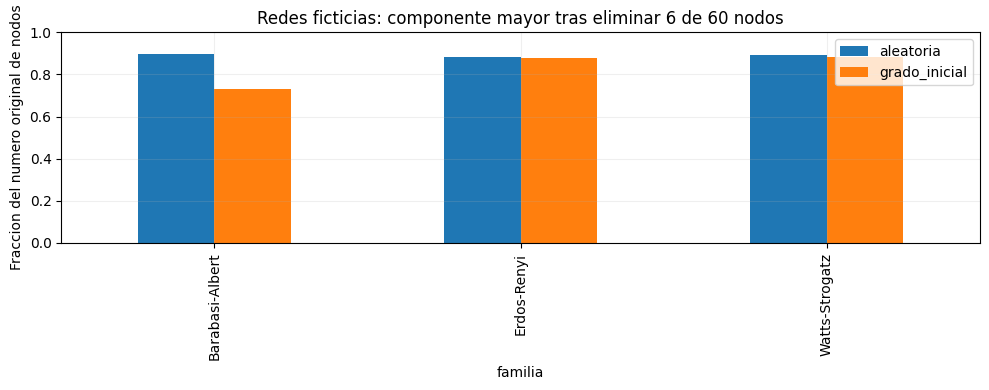

In [7]:
import networkx as nx
filas=[]
for semilla in range(10):
    redes={
      'Erdos-Renyi':nx.erdos_renyi_graph(60,4/59,seed=semilla),
      'Watts-Strogatz':nx.watts_strogatz_graph(60,4,.15,seed=semilla),
      'Barabasi-Albert':nx.barabasi_albert_graph(60,2,seed=semilla)}
    for nombre,g in redes.items():
        componente=max(nx.connected_components(g),key=len)
        aleatorios=np.random.default_rng(semilla).choice(list(g),6,replace=False)
        dirigidos=sorted(g,key=lambda n:(-g.degree(n),n))[:6]
        supervivencia={}
        for regla,salidas in [('aleatoria',aleatorios),('grado_inicial',dirigidos)]:
            restante=g.copy();restante.remove_nodes_from(salidas)
            supervivencia[regla]=len(max(nx.connected_components(restante),key=len))/60
        filas.append({'familia':nombre,'semilla':semilla,'densidad':nx.density(g),
          'clustering':nx.average_clustering(g),'fraccion_componente':len(componente)/60,
          'camino_componente':nx.average_shortest_path_length(g.subgraph(componente)),
          **supervivencia})
topologias=pd.DataFrame(filas)
display(topologias.groupby('familia').agg(['mean','std']).drop(columns='semilla'))
topologias.groupby('familia')[['aleatoria','grado_inicial']].mean().plot.bar(
    ylim=(0,1),title='Redes ficticias: componente mayor tras eliminar 6 de 60 nodos')
plt.ylabel('Fraccion del numero original de nodos');plt.tight_layout();plt.show()

## Bitácora de aprendizaje
Escribe cuatro párrafos: qué esperabas; qué observaste; qué regla explica la diferencia; qué se puede trasladar al problema energético y qué requiere otro análisis. Incluye una variante ejecutada y un resultado que podría refutar tu explicación. Una limitación debe conducir a una pregunta o prueba concreta.